In [50]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from metashapes.shape import Rectangle, Stripe, Triangle, Egg
from metashapes.lattice.basis import Lattice
from metashapes.lattice.unit_cell import UnitCell
from metashapes.lattice.grid import cartesian_grid

dtype = torch.float32
device = 'cuda:0'

In [65]:
# Create lattice for visualisation
Lx = 1.0
Ly = 1.0
nx = 256
ny = 256

lattice = Lattice.rectangular(Lx, Ly)
lattice = lattice.to(dtype=dtype, device=device)

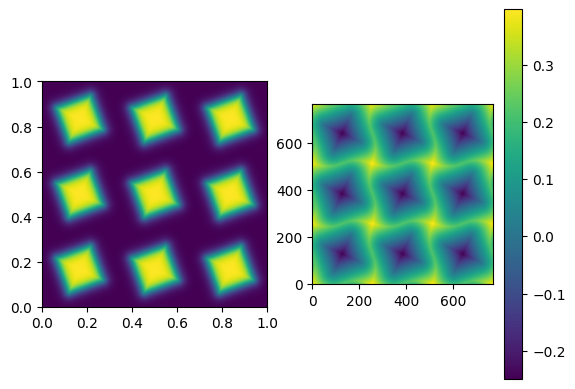

In [3]:
# Rectangle
center        = torch.nn.Parameter(torch.tensor([0.5, 0.5]))
size          = torch.nn.Parameter(torch.tensor([0.5, 0.5]))
angle         = torch.nn.Parameter(torch.tensor(20.0))
corner_radius = torch.tensor(0.02)

rect = Rectangle(center=center, size=size, angle=angle, corner_radius=corner_radius)
rect = rect.to(dtype=dtype, device=device)
rect_cell = UnitCell(lattice=lattice, scene=rect)

image = rect_cell.mask(nx, ny, repeat=(3, 3), cartesian=True, soft=True, softness=0.04)

sdf = rect_cell.rasterize(nx, ny, cartesian=True, repeat=(3, 3))

fc = torch.tensor([[0,0],[1,0],[0,1],[1,1]], dtype=lattice.dtype, device=lattice.device)
cx, cy = lattice.to_cartesian(fc[:,0], fc[:,1])
extent = [cx.min().item(), cx.max().item(), cy.min().item(), cy.max().item()]

plt.figure()
plt.subplot(121)
plt.imshow(image.cpu().detach(), aspect='equal', extent=extent, origin='lower')

plt.subplot(122)
plt.imshow(sdf.cpu().detach(), origin='lower')
plt.colorbar()

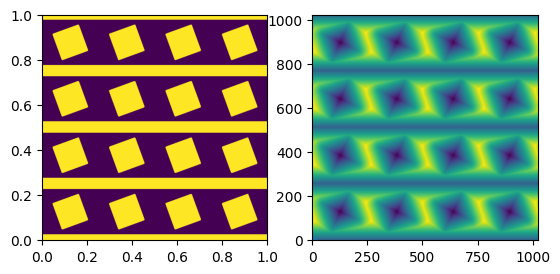

In [4]:
# Stripe
offset        = torch.nn.Parameter(torch.tensor(0.0))
width          = torch.nn.Parameter(torch.tensor(0.2))
axis         = 'x'

stripe = Stripe(offset, width, axis)
stripe = stripe.to(dtype=dtype, device=device)
stripe_cell = UnitCell(lattice=lattice, scene=(stripe.union(rect.rotate(-0, origin=(0.5, 0.5)))))

image = stripe_cell.mask(nx, ny, repeat=(4, 4), cartesian=True)

sdf = stripe_cell.rasterize(nx, ny, cartesian=True, repeat=(4, 4))

fc = torch.tensor([[0,0],[1,0],[0,1],[1,1]], dtype=lattice.dtype, device=lattice.device)
cx, cy = lattice.to_cartesian(fc[:,0], fc[:,1])
extent = [cx.min().item(), cx.max().item(), cy.min().item(), cy.max().item()]

plt.figure()
plt.subplot(121)
plt.imshow(image.cpu().detach(), aspect='equal', extent=extent, origin='lower')

plt.subplot(122)
plt.imshow(sdf.cpu().detach(), origin='lower')
plt.scatter(stripe_cell.boundary_points()[:,0], stripe_cell.boundary_points()[:,1], s = 10)

In [5]:
stripe_cell.boundary_points().shape

(2316, 2)

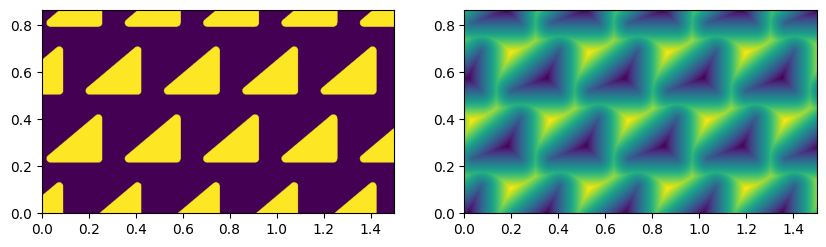

In [49]:
# Triangle
center        = torch.nn.Parameter(torch.tensor([0.0, 0.0]))
base          = torch.nn.Parameter(torch.tensor(0.8))
alpha          = torch.nn.Parameter(torch.tensor(40.0))
beta          = torch.nn.Parameter(torch.tensor(90.0))
angle         = torch.nn.Parameter(torch.tensor(0.0))
corner_radius = torch.tensor(0.05)

tri = Triangle(center, base, alpha, beta, angle, corner_radius)
tri = tri.to(dtype=dtype, device=device)
tri_cell = UnitCell(lattice=lattice, scene=tri)

image = tri_cell.mask(nx, ny, repeat=(3, 3), cartesian=True, soft=False, softness=0.04)

sdf = tri_cell.rasterize(nx, ny, cartesian=True, repeat=(3, 3))

fc = torch.tensor([[0,0],[1,0],[0,1],[1,1]], dtype=lattice.dtype, device=lattice.device)
cx, cy = lattice.to_cartesian(fc[:,0], fc[:,1])
extent = [cx.min().item(), cx.max().item(), cy.min().item(), cy.max().item()]

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(image.cpu().detach(), aspect='equal', extent=extent, origin='lower')

plt.subplot(122)
plt.imshow(sdf.cpu().detach(), aspect='equal', extent=extent, origin='lower')

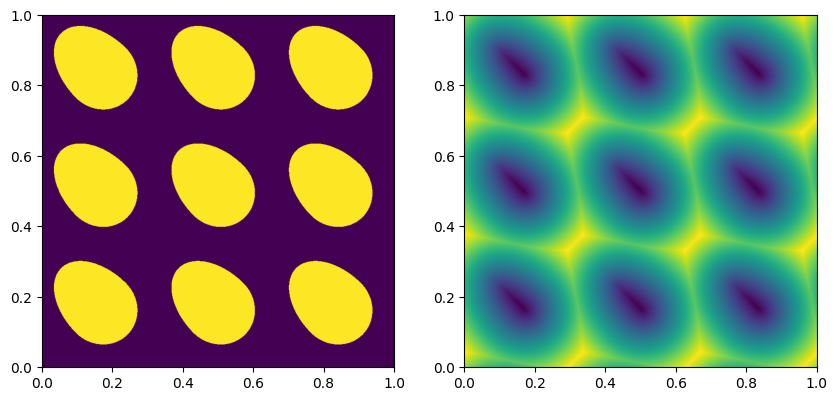

In [67]:
# Egg
center        = torch.nn.Parameter(torch.tensor([0.5, 0.5]))
width          = torch.nn.Parameter(torch.tensor(0.6))
height          = torch.nn.Parameter(torch.tensor(0.8))
skew          = torch.nn.Parameter(torch.tensor(0.2))
angle         = torch.nn.Parameter(torch.tensor(45.0))

egg = Egg(center, width, height, skew, angle)
egg = egg.to(dtype=dtype, device=device)
egg_cell = UnitCell(lattice=lattice, scene=egg)

image = egg_cell.mask(nx, ny, repeat=(3, 3), cartesian=True, soft=False, softness=0.04)

sdf = egg_cell.rasterize(nx, ny, cartesian=True, repeat=(3, 3))

fc = torch.tensor([[0,0],[1,0],[0,1],[1,1]], dtype=lattice.dtype, device=lattice.device)
cx, cy = lattice.to_cartesian(fc[:,0], fc[:,1])
extent = [cx.min().item(), cx.max().item(), cy.min().item(), cy.max().item()]

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(image.cpu().detach(), aspect='equal', extent=extent, origin='lower')

plt.subplot(122)
plt.imshow(sdf.cpu().detach(), aspect='equal', extent=extent, origin='lower')